In [2]:
#import Libraries
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


#metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import DataPreprocessor

### Load and Preprocess Data

In [3]:
preprocessor = DataPreprocessor()

df = preprocessor.load_data('../data/telco_comm_churn.csv')

Laoding data from ../data/telco_comm_churn.csv ...

 Data Loaded


In [4]:
X_train, X_test, y_train, y_test = preprocessor.prepare_data(df)


STARTING DATA PREPROCESSING PIPELINE
Filled missing values 

Creating new features...
Tenure range: 0 to 72
✅ Created 3 new features
   - tenure_group: [0 2 1 3]
   - avg_monthly_per_tenure: min=9.18, max=1397.47
   - num_services: min=0, max=5
   - Encoded MultipleLines: 3 classes
   - Encoded InternetService: 3 classes
   - Encoded OnlineSecurity: 3 classes
   - Encoded OnlineBackup: 3 classes
   - Encoded DeviceProtection: 3 classes
   - Encoded TechSupport: 3 classes
   - Encoded StreamingTV: 3 classes
   - Encoded StreamingMovies: 3 classes
   - Encoded Contract: 3 classes
   - Encoded PaymentMethod: 4 classes
✅ Encoded 15 categorical features

📊 Train-Test Split:
   Train set: 5634 samples (80%)
   Test set: 1409 samples (20%)
FEATURES SCALED!!!

✅ PREPROCESSING COMPLETE


In [8]:
print(f"\n📊 Final Dataset Summary:")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Churn rate (train): {y_train.mean()*100:.2f}%")
print(f"Churn rate (test): {y_test.mean()*100:.2f}%")


📊 Final Dataset Summary:
Training samples: 5634
Test samples: 1409
Number of features: 22
Churn rate (train): 26.54%
Churn rate (test): 26.54%


### Model Training

In [9]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree' : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state = 42),
    'XGBoost' : XGBClassifier(n_estimators = 100, max_depth = 5, random_state=42, eval_metric ='logloss')    
}
models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=10, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_st

#### Train all Models

In [10]:
results = {}

print("\nTRAINING STARTED!!!!")

for name, model in models.items():
    print(f"\nTraining started for {name}...")
    #train
    model.fit(X_train, y_train)
    
    #predict
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    #calculate Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    
    #store the result
    results[name] = {
        'model' : model,
        'accuracy' : accuracy,
        'precision' : precision,
        'recall':recall,
        'f1' : f1, 
        'roc_auc': roc_auc,
        'y_pred' : y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    
    print(f"{name} trained")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC : {roc_auc:.4f}")
    
    
print("\nTRAINING COMPLETED!!!!")


TRAINING STARTED!!!!

Training started for Logistic Regression...
Logistic Regression trained
Accuracy: 0.8041
ROC AUC : 0.8458

Training started for Decision Tree...
Decision Tree trained
Accuracy: 0.7601
ROC AUC : 0.7542

Training started for Random Forest...
Random Forest trained
Accuracy: 0.8020
ROC AUC : 0.8372

Training started for Gradient Boosting...
Gradient Boosting trained
Accuracy: 0.8013
ROC AUC : 0.8427

Training started for XGBoost...
XGBoost trained
Accuracy: 0.7807
ROC AUC : 0.8203

TRAINING COMPLETED!!!!


#### Model Comparison

In [11]:
model_compare = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'F1-Score': [results[m]['f1'] for m in results],
    'ROC-AUC': [results[m]['roc_auc'] for m in results],
    'Recall': [results[m]['recall'] for m in results],
    
})

model_compare

,Model,Accuracy,Precision,F1-Score,ROC-AUC,Recall
0,Logistic Regression,0.804116,0.661184,0.592920,0.845821,0.537433
1,Decision Tree,0.760114,0.549724,0.540761,0.754229,0.532086
2,Random Forest,0.801987,0.664360,0.579186,0.837166,0.513369
3,Gradient Boosting,0.801278,0.664336,0.575758,0.842708,0.508021
4,XGBoost,0.780696,0.605178,0.547584,0.820349,0.500000


In [12]:
model_compare = model_compare.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(model_compare.to_string(index=False))

              Model  Accuracy  Precision  F1-Score  ROC-AUC   Recall
Logistic Regression  0.804116   0.661184  0.592920 0.845821 0.537433
  Gradient Boosting  0.801278   0.664336  0.575758 0.842708 0.508021
      Random Forest  0.801987   0.664360  0.579186 0.837166 0.513369
            XGBoost  0.780696   0.605178  0.547584 0.820349 0.500000
      Decision Tree  0.760114   0.549724  0.540761 0.754229 0.532086


##### Save Model to .csv Form

In [13]:
model_compare.to_csv('../reports/model_comparison.csv', index = False)
print("Saved: Model comparison file in reports")

Saved: Model comparison file in reports


#### Model Visualisation

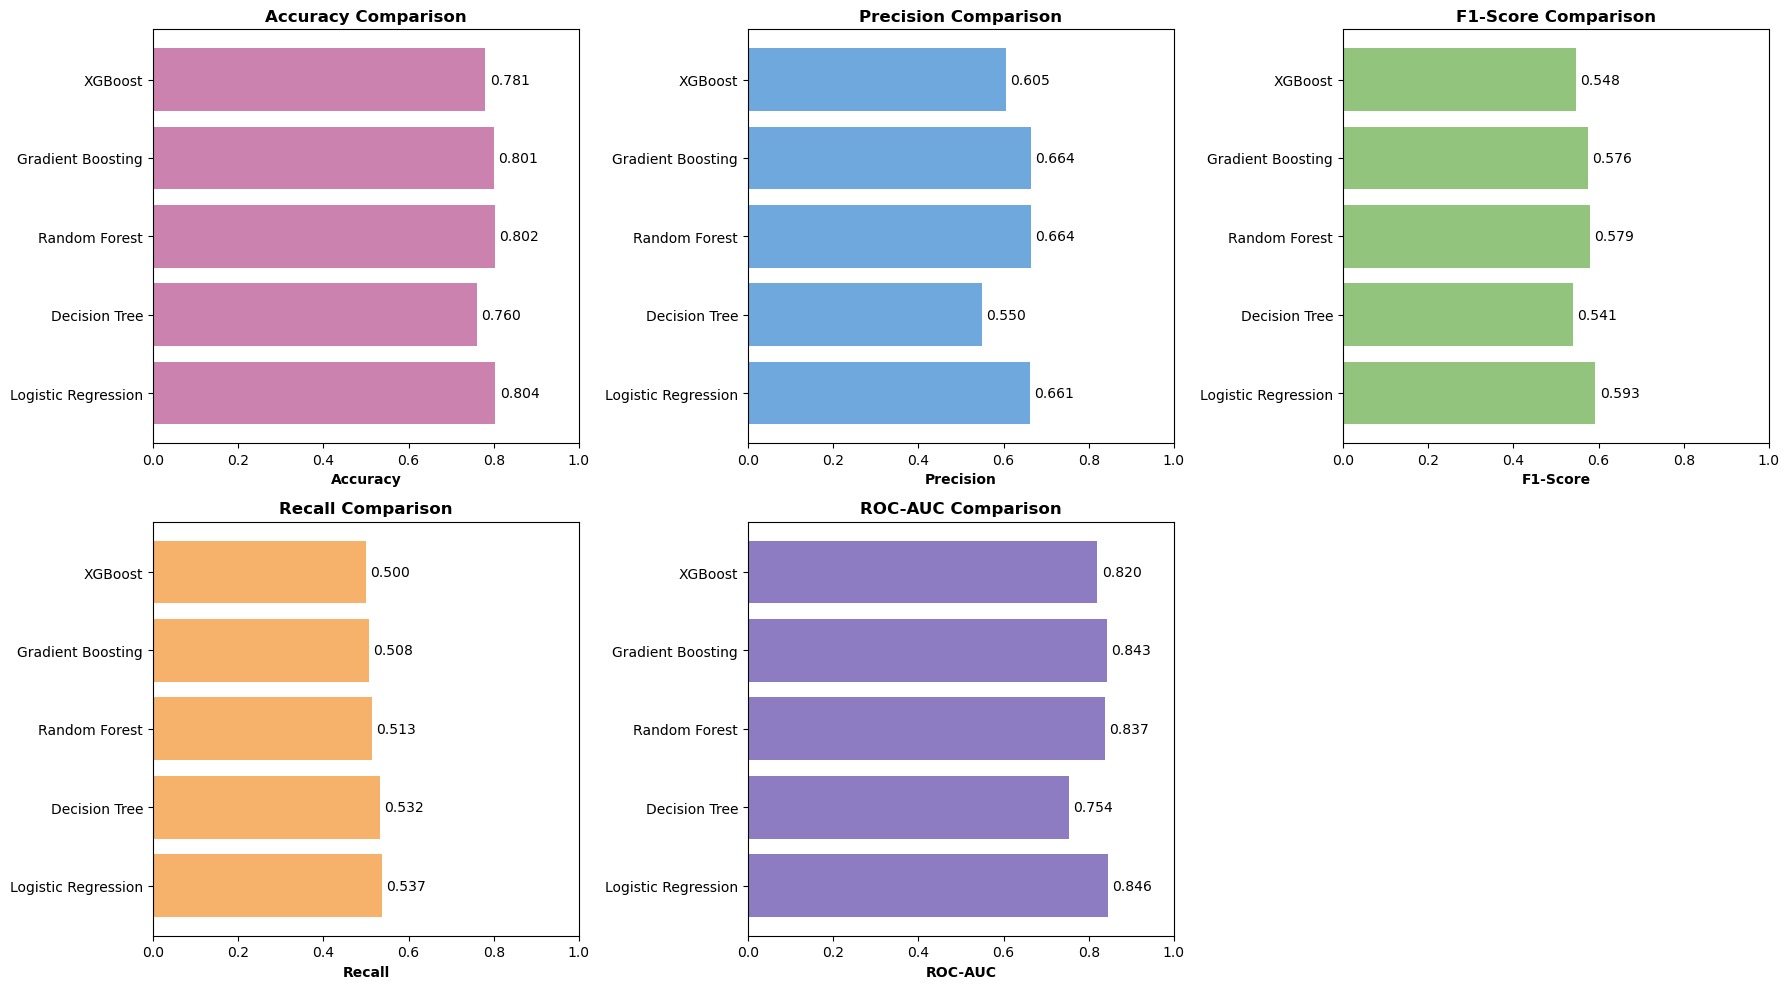

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()

metrics = ['accuracy', 'precision', 'f1', 'recall', 'roc_auc']
metrics_names = ['Accuracy', 'Precision', 'F1-Score', 'Recall', 'ROC-AUC']

colors = ['#CB82AF', '#6FA8DC', '#93C47D', '#F6B26B', '#8E7CC3']

for idx, (metric, metric_name) in enumerate(zip(metrics, metrics_names)):

    values = [results[m][metric] for m in results]
    model_names = list(results.keys())

    axes[idx].barh(model_names, values, color=colors[idx])
    axes[idx].set_xlabel(metric_name, fontweight='bold')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_title(f'{metric_name} Comparison', fontweight='bold')

    for i, v in enumerate(values):
        axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center')

fig.delaxes(axes[5])
plt.tight_layout()
plt.savefig('../reports/model_comparison_graph.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
best_model_name = model_compare.iloc[0]['Model']
best_model_result = results[best_model_name]

# best_model_name, best_model_result

print(f"Best Model : {best_model_name}")

Best Model : Logistic Regression


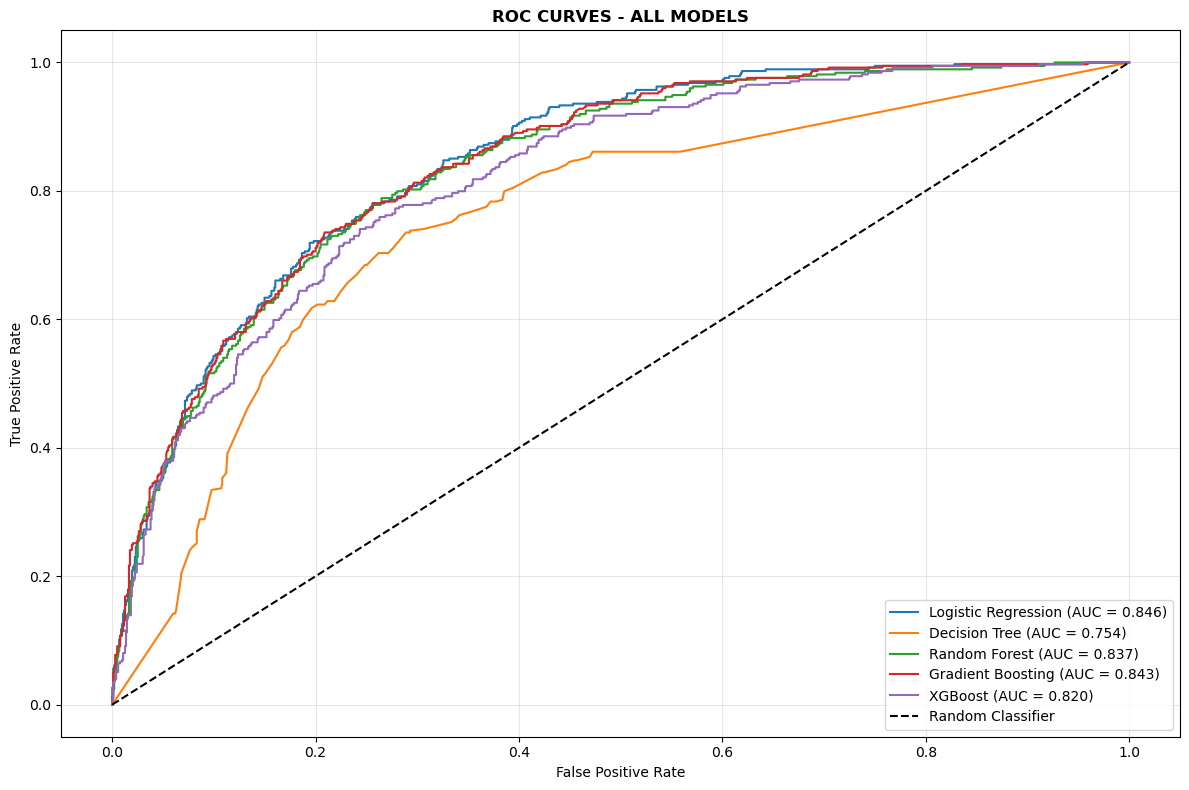

In [17]:
plt.figure(figsize=(12,8))

for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label = f"{name} (AUC = {results[name]['roc_auc']:.3f})")
    
    
plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVES - ALL MODELS', fontweight = 'bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curves.png', dpi=300, bbox_inches='tight')

plt.show()

In [18]:
if hasattr(best_model_result['model'], 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_model_result['model'].feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance, y='Feature', x='Importance', palette='viridis')
    plt.title(f'Top 15 Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Saved: reports/feature_importance.png")
    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))
else:
    print(f"\n⚠️  {best_model_name} doesn't have feature_importances_ attribute")


⚠️  Logistic Regression doesn't have feature_importances_ attribute


In [19]:
import joblib

best_model = best_model_result['model']
model_path = f'../models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl'

joblib.dump(best_model, model_path)
joblib.dump(preprocessor, '../models/preprocessor.pkl')
print("\n Model Saved")
print(f"Modle Path : {model_path}")


 Model Saved
Modle Path : ../models/best_model_logistic_regression.pkl


#### Final Summary

In [20]:
print("\n" + "="*60)
print("PROJECT SUMMARY")
print("="*60)
print(f"\n🎯 Best Model: {best_model_name}")
print(f"   ROC-AUC Score: {best_model_result['roc_auc']:.4f}")
print(f"   Accuracy: {best_model_result['accuracy']:.4f}")
print(f"   F1-Score: {best_model_result['f1']:.4f}")

print(f"\n📁 Generated Files:")
print("   - reports/model_comparison.csv")
print("   - reports/model_comparison_visual.png")
print("   - reports/confusion_matrix.png")
print("   - reports/roc_curves.png")
print("   - reports/feature_importance.png")
print("   - models/best_model_*.pkl")
print("   - models/preprocessor.pkl")

print("\n✅ PROJECT COMPLETE!")
print("="*60)


PROJECT SUMMARY

🎯 Best Model: Logistic Regression
   ROC-AUC Score: 0.8458
   Accuracy: 0.8041
   F1-Score: 0.5929

📁 Generated Files:
   - reports/model_comparison.csv
   - reports/model_comparison_visual.png
   - reports/confusion_matrix.png
   - reports/roc_curves.png
   - reports/feature_importance.png
   - models/best_model_*.pkl
   - models/preprocessor.pkl

✅ PROJECT COMPLETE!
